In [5]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt


In [7]:
data=pd.read_csv('/content/drive/MyDrive/Data engg and genai internship/student_performance.csv')
df = pd.DataFrame(data)
df["total_score"] = df["math_score"] + df["programming_score"]
print(df)

    student_id            name  age  gender        department  semester  \
0         1001    Aarav Sharma   19    Male  Computer Science         2   
1         1002     Priya Patel   20  Female  Computer Science         2   
2         1003     Rohit Verma   19    Male       Electronics         2   
3         1004     Sneha Reddy   20  Female        Mechanical         2   
4         1005      Arjun Nair   19    Male  Computer Science         2   
5         1006     Meera Joshi   20  Female       Electronics         2   
6         1007     Kiran Kumar   21    Male             Civil         2   
7         1008     Divya Singh   19  Female  Computer Science         2   
8         1009    Rahul Mishra   20    Male        Mechanical         2   
9         1010      Ananya Das   19  Female  Computer Science         2   
10        1011     Vikram Iyer   20    Male       Electronics         2   
11        1012     Pooja Gupta   19  Female             Civil         2   
12        1013      Sures

In [8]:
conn = sqlite3.connect("students.db")
df.to_sql("students", conn, if_exists="replace", index=False)

30

In [9]:
query1 = """
SELECT department, AVG(math_score) AS avg_math
FROM students
GROUP BY department
"""
panel1 = pd.read_sql_query(query1, conn)
print(panel1)

         department   avg_math
0             Civil  63.400000
1  Computer Science  85.615385
2       Electronics  71.000000
3        Mechanical  71.000000


In [10]:
query2 = """
SELECT department, COUNT(*) AS student_count
FROM students
GROUP BY department
"""
panel2 = pd.read_sql_query(query2, conn)
print(panel2)

         department  student_count
0             Civil              5
1  Computer Science             13
2       Electronics              6
3        Mechanical              6


In [11]:
query3 = """
SELECT name, total_score
FROM students
ORDER BY total_score DESC
LIMIT 8
"""
panel3 = pd.read_sql_query(query3, conn)
print(panel3)

             name  total_score
0      Ananya Das          192
1     Tanvi Mehta          189
2      Arjun Nair          187
3  Akanksha Yadav          185
4  Swati Kulkarni          182
5     Divya Singh          181
6    Aarav Sharma          176
7       Amit Bose          175


In [12]:
query4 = """
SELECT gender, AVG(attendance_percentage) AS avg_attendance
FROM students
GROUP BY gender
"""
panel4 = pd.read_sql_query(query4, conn)
print(panel4)

   gender  avg_attendance
0  Female       88.533333
1    Male       80.466667


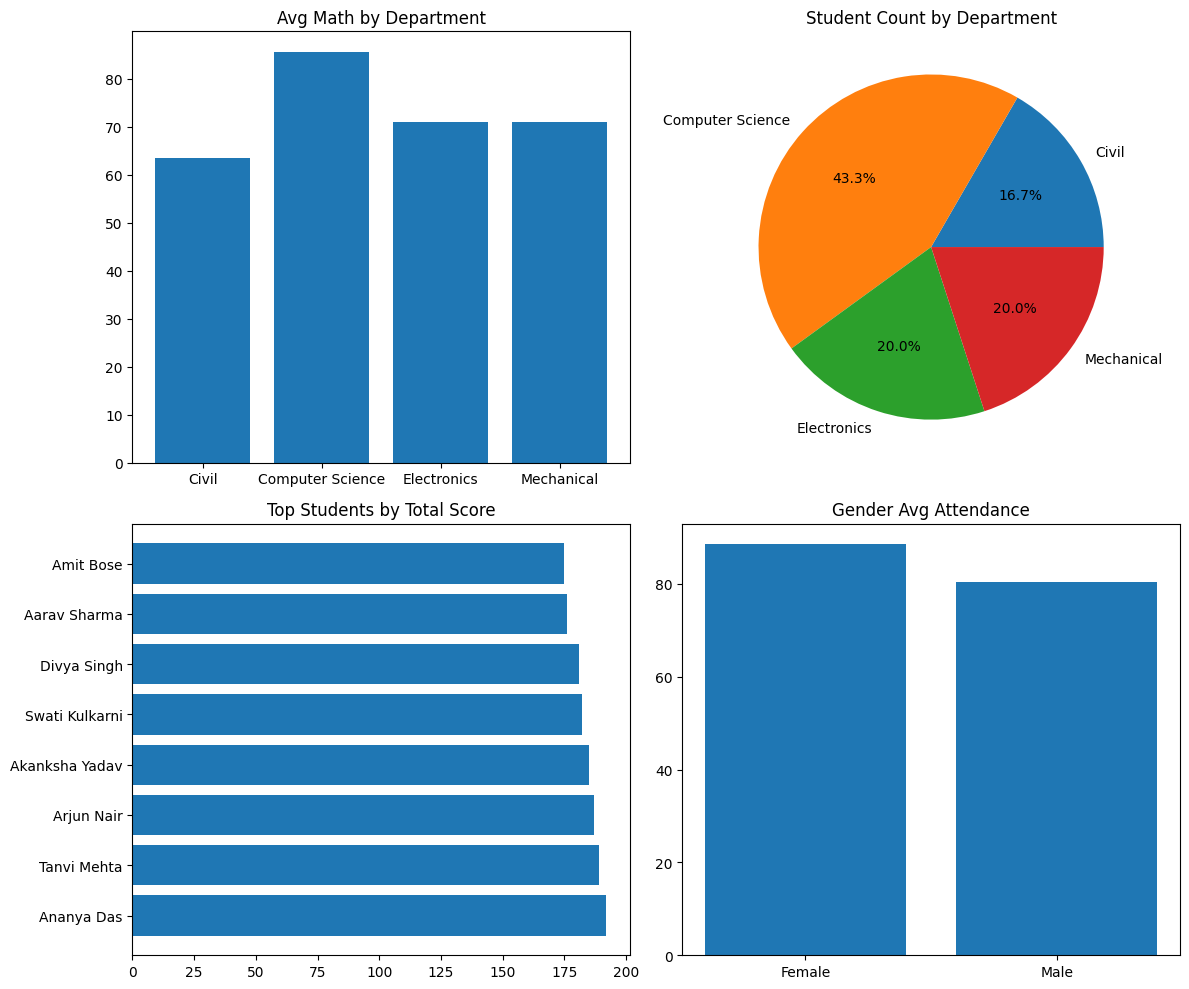

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0,0].bar(panel1["department"], panel1["avg_math"])
axes[0,0].set_title("Avg Math by Department")

axes[0,1].pie(panel2["student_count"],labels=panel2["department"],autopct='%1.1f%%')
axes[0,1].set_title("Student Count by Department")

axes[1,0].barh(panel3["name"], panel3["total_score"])
axes[1,0].set_title("Top Students by Total Score")

axes[1,1].bar(panel4["gender"], panel4["avg_attendance"])
axes[1,1].set_title("Gender Avg Attendance")

plt.tight_layout()
plt.show()

In [1]:
print("------------Practice Question------------")

------------Practice Question------------


In [5]:
import pandas as pd
import sqlite3
conn = sqlite3.connect("students.db")
query = """
SELECT AVG(programming_score) AS avg_programming
FROM students
WHERE gender = 'Female';
"""
result = pd.read_sql_query(query, conn)
print(result)

   avg_programming
0             70.2


In [6]:
import pandas as pd
import sqlite3
conn = sqlite3.connect("students.db")
query = """
SELECT *
FROM students
WHERE math_score > 80;
"""
result = pd.read_sql_query(query, conn)
print(result)

    student_id            name  age  gender        department  semester  \
0         1001    Aarav Sharma   19    Male  Computer Science         2   
1         1005      Arjun Nair   19    Male  Computer Science         2   
2         1008     Divya Singh   19  Female  Computer Science         2   
3         1010      Ananya Das   19  Female  Computer Science         2   
4         1013      Suresh Rao   21    Male  Computer Science         2   
5         1016    Ritu Agarwal   20  Female       Electronics         2   
6         1018  Swati Kulkarni   19  Female  Computer Science         2   
7         1022     Tanvi Mehta   19  Female  Computer Science         2   
8         1025       Amit Bose   19    Male  Computer Science         2   
9         1027   Gaurav Shukla   21    Male  Computer Science         2   
10        1030  Akanksha Yadav   19  Female  Computer Science         2   

    math_score  science_score  english_score  programming_score  \
0           85             78   

In [7]:
import pandas as pd
import sqlite3
conn = sqlite3.connect("students.db")
query = """
SELECT department, AVG(attendance_percentage) AS avg_attendance
FROM students
GROUP BY department
HAVING AVG(attendance_percentage) > 85;
"""
result = pd.read_sql_query(query, conn)
print(result)

         department  avg_attendance
0  Computer Science       90.692308


In [8]:
import pandas as pd
import sqlite3
conn = sqlite3.connect("students.db")
query = """
SELECT * FROM students;
"""
result = pd.read_sql_query(query, conn)
print(result)

    student_id            name  age  gender        department  semester  \
0         1001    Aarav Sharma   19    Male  Computer Science         2   
1         1002     Priya Patel   20  Female  Computer Science         2   
2         1003     Rohit Verma   19    Male       Electronics         2   
3         1004     Sneha Reddy   20  Female        Mechanical         2   
4         1005      Arjun Nair   19    Male  Computer Science         2   
5         1006     Meera Joshi   20  Female       Electronics         2   
6         1007     Kiran Kumar   21    Male             Civil         2   
7         1008     Divya Singh   19  Female  Computer Science         2   
8         1009    Rahul Mishra   20    Male        Mechanical         2   
9         1010      Ananya Das   19  Female  Computer Science         2   
10        1011     Vikram Iyer   20    Male       Electronics         2   
11        1012     Pooja Gupta   19  Female             Civil         2   
12        1013      Sures

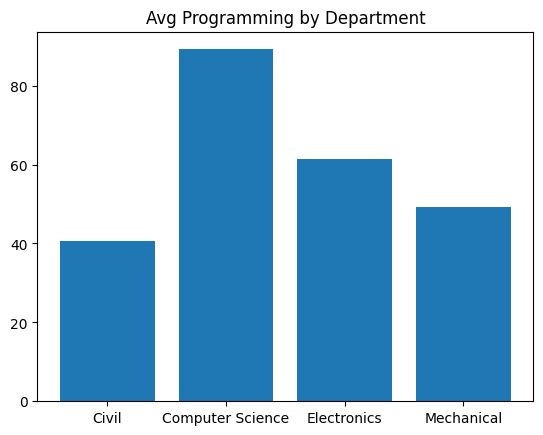

In [9]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
conn = sqlite3.connect("students.db")
query = """
SELECT department, AVG(programming_score) AS avg_programming
FROM students
GROUP BY department;
"""
panel1 = pd.read_sql_query(query, conn)
axes = plt.gca()
axes.bar(panel1["department"], panel1["avg_programming"])
axes.set_title("Avg Programming by Department")
plt.show()

In [13]:
import pandas as pd
import sqlite3

conn = sqlite3.connect("students.db")

# LEFT JOIN
query1 = """
SELECT students.name, departments.department
FROM students
LEFT JOIN departments
ON students.dept_id = departments.dept_id;
"""
print("LEFT JOIN")
print(pd.read_sql_query(query1, conn))

# RIGHT JOIN alternative
query2 = """
SELECT students.name, departments.department
FROM departments
LEFT JOIN students
ON students.dept_id = departments.dept_id;
"""
print("\nRIGHT JOIN")
print(pd.read_sql_query(query2, conn))

# FULL JOIN alternative
query3 = """
SELECT students.name, departments.department
FROM students
LEFT JOIN departments
ON students.dept_id = departments.dept_id
UNION
SELECT students.name, departments.department
FROM departments
LEFT JOIN students
ON students.dept_id = departments.dept_id;
"""
print("\nFULL JOIN")
print(pd.read_sql_query(query3, conn))

LEFT JOIN
    name department
0   Arun        CSE
1  Priya        ECE
2  Kavin       None

RIGHT JOIN
    name department
0   Arun        CSE
1  Priya        ECE

FULL JOIN
    name department
0   Arun        CSE
1  Kavin       None
2  Priya        ECE
